## EDA of Distribution

#### Load in Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from rich import print

#### Load in Data

In [2]:
df = pd.read_csv("/Users/justinvhuang/Desktop/ISYE-CSE-MGT-6748-Group-1/data/postings.csv", index_col=0)

/var/folders/vz/cyjrzm0x74q21sb72nhkdfmr0000gn/T/ipykernel_27689/2523274885.py:1: DtypeWarning: Columns (5,11,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/justinvhuang/Desktop/ISYE-CSE-MGT-6748-Group-1/data/postings.csv", index_col=0)


#### EDA

In [3]:
len(df)

1226569

In [4]:
len(df.columns)

122

In [5]:
def count_words(text):
    words = text.split()
    return len(words)
df['word_count'] = df['body'].apply(count_words)

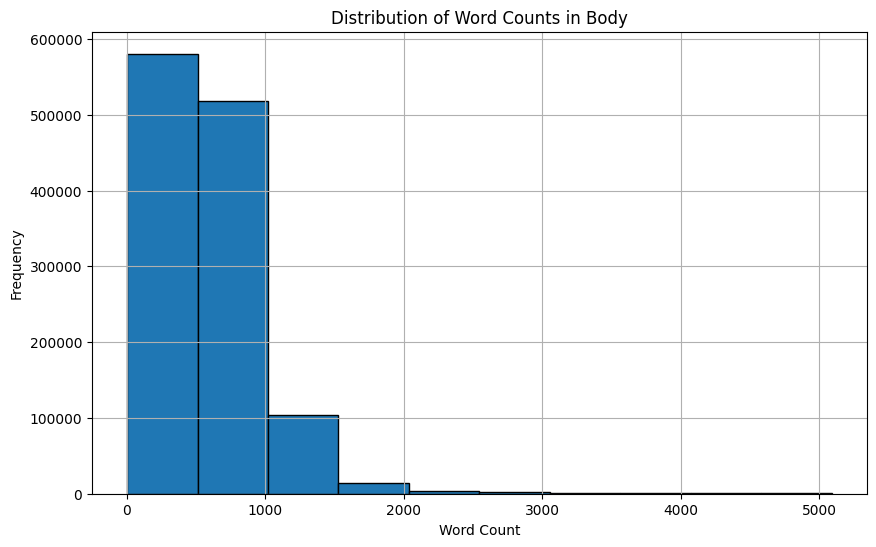

In [6]:
# Plot the distribution of word counts
plt.figure(figsize=(10, 6))
plt.hist(df['word_count'], bins=10, edgecolor='black')
plt.title('Distribution of Word Counts in Body')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [7]:
df2 = df.drop_duplicates(subset=['body'])

In [8]:
len(df2)

1175523

In [9]:
df2['naics2_name'].nunique()

21

In [10]:
df3 = df2[df2['naics2_name'] == 'Unclassified Industry'].reset_index(drop = True)

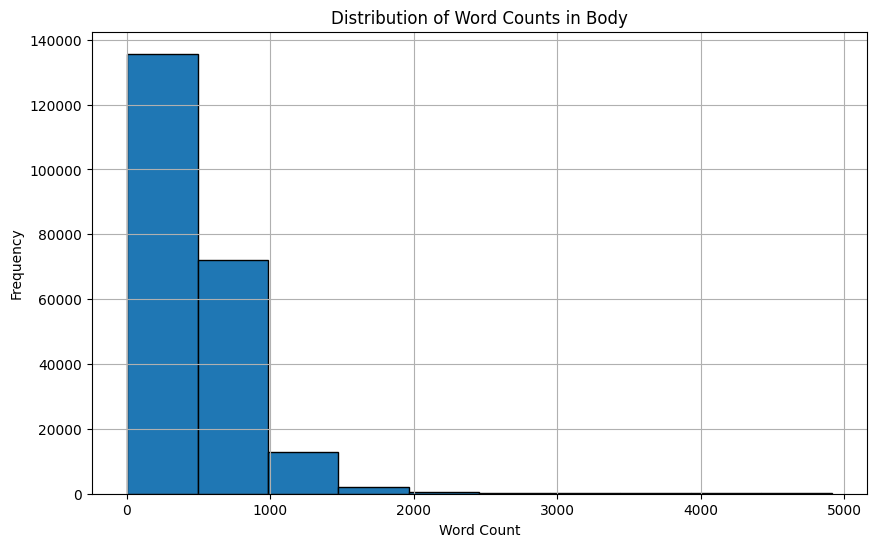

In [11]:
# Plot the distribution of word counts
plt.figure(figsize=(10, 6))
plt.hist(df3['word_count'], bins=10, edgecolor='black')
plt.title('Distribution of Word Counts in Body')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [12]:
len(df3)

224694

In [13]:
len(df3[df3['word_count']<=50]['body'])

5382

In [14]:
df3[df3['word_count']<=50]['body']

7         Welder wanted (Rancho Cucamonga) compensation:...
75        Welder/helper (Largo) compensation: Tbd employ...
102       Welder /Fabricator (Prescott/Chino) compensati...
161       $21.00\nPer Hour\nPosition range in The Villag...
217       at Aerotek.com.\nThe company is an equal oppor...
                                ...                        
224334    un Auto welder (Holland) compensation: To be d...
224612    welder compensation: 25 and up employment type...
224634    un WELDER (raleigh) 409 donald ross drive 105-...
224637    un Welder/Welders helper (bakersfield area) co...
224681    Mig Welder & a Metal Fabricator/ Fitter\nConfi...
Name: body, Length: 5382, dtype: object

In [15]:
print('Example 1:')
print(df3[df3['word_count']<=50]['body'][224334])
print('Example 2:')
print(df3[df3['word_count']<100]['body'][224681])
print('Example 3:')
print(df3[df3['word_count']<=50]['body'][217])

Example 1:

un Auto welder (Holland) compensation: To be determined Need a professional welder who can add reinforcement to a 
rusty unibody on a 2002 Grand Cherokee Jeep Do NOT contact this poster with unsolicited services or offers. post 
id: 7702698387 updated: [ ]

Example 2:

Mig Welder & a Metal Fabricator/ Fitter
Confidential
Pottstown, Pennsylvania
Metal Fabrication Shop in Boyertown looking for Mig Welder & a Metal Fabricator/ Fitter. Feel free to call 
484-614-3790 ask for Bill.
recblid eykaoxxa6kui1ogkct12eccfche443
Not Specified
Job Information
Position Type:
Full Time

Example 3:

at Aerotek.com.
The company is an equal opportunity employer and will consider all applications without regards to race, sex, age, 
color, religion, national origin, veteran status, disability, sexual orientation, gender identity, genetic 
information or any characteristic protected by law.


 
Employer Research

In [16]:
df4 = df3[df3['word_count'] > 50].reset_index(drop = True)

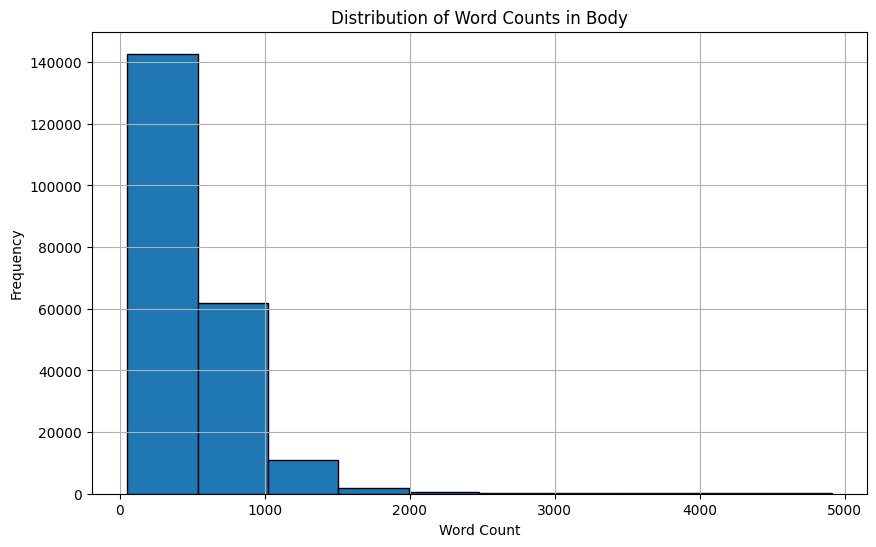

In [17]:
# Plot the distribution of word counts
plt.figure(figsize=(10, 6))
plt.hist(df4['word_count'], bins=10, edgecolor='black')
plt.title('Distribution of Word Counts in Body')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

#### Save Unclassified Postings

In [18]:
df4.to_csv('/Users/justinvhuang/Desktop/ISYE-CSE-MGT-6748-Group-1/data/unclassified_postings_v2.csv')